In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys
from tqdm import tqdm

import jax
from jax import jit
import jax.numpy as jnp

import numpy as np
import healpy as hp
import pickle
from functools import partial

os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../../notebooks/matplotlibrc")

[gpu(id=0)]


In [2]:
sys.path.append("../..")
from models.np_model import NPModel
from simulations.wrapper import simulator_for_model
from models.scd import dnds
from likelihoods.npll_jax import log_like_np

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
npmodel = NPModel(
    non_poissonian=True, l_max=2,
    dif_names=["ModelO", "ModelA", "ModelF"],
    bulge_hybrid=True,
    bulge_template_names=["mcdermott2022", "mcdermott2022_bbp", "mcdermott2022_x", "macias2019", "coleman2019"],
    vary_gamma=True,
    vary_disk=True,
    ps_cat="3fgl", r_outer=25, band_mask_range=2.,
    nside=128, n_exp=1, debug_model=False,
)

Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/validating/fit_np_to_np/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


## 1. Generate counts

### 1.1 everything

In [5]:
S_Sps_arr = [[5., 0.01], [2.5, 2.5], [0.01, 5.]]
for S_gce, Sps_gce in S_Sps_arr:
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"
    print(run_name)

    var_dict = dict(
        theta_pib = np.array([1., 0., 0.]), # O A F
        theta_ics = np.array([1., 0., 0.]),
        S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
        Sps_dsk = 1.3, zs = 0.5, C = 2.5,
        S_gce = S_gce, gamma_poiss = 0.9, f_bulge_poiss = 0.2,
        Sps_gce = Sps_gce, gamma_ps = 1.2, f_bulge_ps = 0.3,
        theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
        theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
        n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
        n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
        Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
    )
    pickle.dump(var_dict, open(f"truth-{run_name}.p", 'wb'))

    counts = simulator_for_model(npmodel, var_dict)
    np.save(f"counts-{run_name}.npy", counts)

S5.000Sps0.010
S2.500Sps2.500
S0.010Sps5.000


### 1.2 bare: just gce

In [66]:
S_Sps_arr = [[5., 0.01], [2.5, 2.5], [0.01, 5.]]
for S_gce, Sps_gce in S_Sps_arr:
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"
    print(run_name)

    var_dict = dict(
        theta_pib = np.array([1., 0., 0.]), # O A F
        theta_ics = np.array([1., 0., 0.]),
        S_iso = 0., S_bub = 0., S_psc = 0., S_pib = 0., S_ics = 0.,
        Sps_dsk = 0., zs = 0.5, C = 2.5,
        S_gce = S_gce, gamma_poiss = 0.9, f_bulge_poiss = 0.2,
        Sps_gce = Sps_gce, gamma_ps = 1.2, f_bulge_ps = 0.3,
        theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
        theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
        n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
        n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
        Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
    )
    pickle.dump(var_dict, open(f"truth-{run_name}-bare.p", 'wb'))

    counts = simulator_for_model(npmodel, var_dict)
    np.save(f"counts-{run_name}-bare.npy", counts)

S5.000Sps0.010
S2.500Sps2.500
S0.010Sps5.000


### 1.3 view

S5.000Sps0.010
S2.500Sps2.500
S0.010Sps5.000


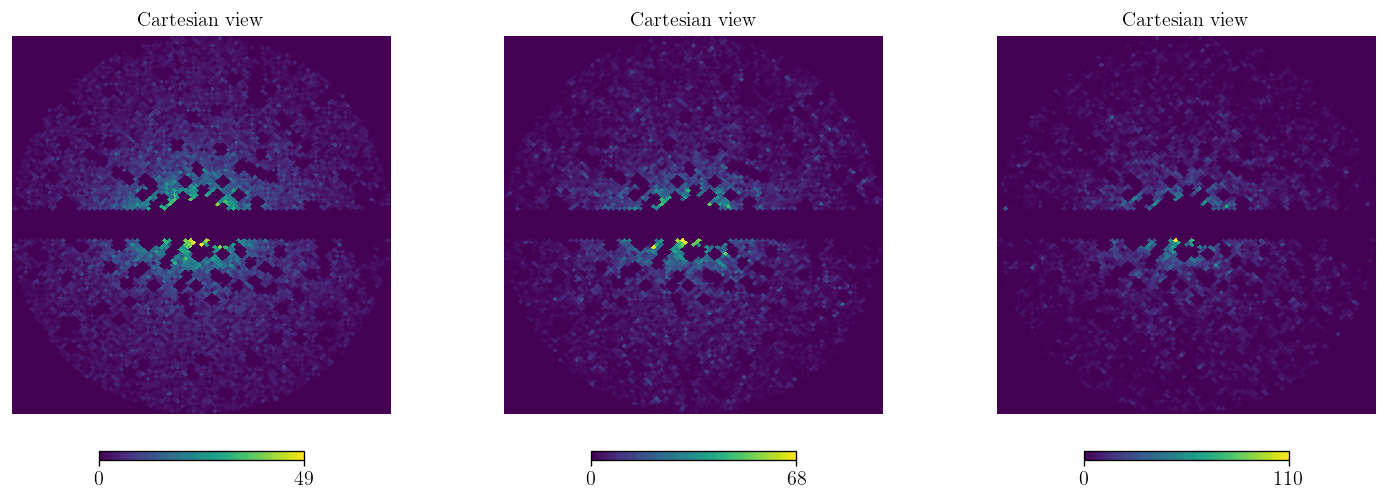

In [67]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

S_Sps_arr = [[5., 0.01], [2.5, 2.5], [0.01, 5.]]
ll_arr_arr = []
for i, (S_gce, Sps_gce) in enumerate(S_Sps_arr):
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"
    print(run_name)

    counts = jnp.array(jnp.load(f"counts-{run_name}-bare.npy"), dtype=np.int32)

    plt.sca(axs[i])
    hp.cartview(counts, lonra=[-25, 25], latra=[-25, 25], hold=True)

In [ ]:
z = jnp.load(f"counts-S0.010Sps5.000-bare.npy")

In [ ]:
npmodel.normalization_mask.shape

(196608,)

In [ ]:
z.shape

(196608,)

In [ ]:
np.mean(z[~npmodel.normalization_mask])

Array(0.04835987, dtype=float32)

In [8]:
from models.scd import dnds
from models.psf import KingPSF

In [12]:
var_dict = dict(
        n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
    )

In [44]:
m = npmodel
vd = var_dict

nm = m.normalization_mask
temps_poiss = [np.array(m.temp_bub) / np.mean(m.temp_bub[~nm])]
theta = [0.01]

temps_ps = [np.array(m.nfw_template.get_NFW2_template(gamma=1.0))]
theta += [1.0, vd['n1_gce'], vd['n2_gce'], vd['n3_gce'], vd['sb1_gce'], vd['lambdas_gce'] * vd['sb1_gce']]

mask_sim = np.zeros_like(m.data, dtype=bool) # simulate all
mask_normalize_counts = np.array(m.normalization_mask)
mask_roi = np.array(m.mask_roi)

kp = KingPSF()
psf_r_func = lambda r: kp.psf_fermi_r(r)
exp_map = np.array(m.exposure_map)

In [45]:
the_map = np.zeros(np.sum(~mask_sim))
s_ary = np.logspace(-1, 2, 100)

In [46]:
norm_gce = theta[0] / np.mean(temps_poiss[0][~mask_normalize_counts])

In [47]:
norms_poiss = theta[1 : len(temps_poiss)]

In [48]:
# Normalize PS map to get correct counts/pix in ROI
# and construct appropriate dnds arrays for each PS template

dnds_ary = []
idx_theta_ps = len(temps_poiss)
for temp_ps in temps_ps:
    dnds_ary_temp = dnds(s_ary, theta[idx_theta_ps : idx_theta_ps + 6])
    s_exp = np.trapz(s_ary * dnds_ary_temp, s_ary)
    temp_ratio = np.sum(temp_ps[~mask_normalize_counts]) / np.sum(temp_ps)
    exp_ratio = np.mean(exp_map[~mask_normalize_counts]) / np.mean(exp_map)
    dnds_ary_temp_sky = (dnds_ary_temp/s_exp) * theta[idx_theta_ps] * np.sum(~mask_normalize_counts) / temp_ratio / exp_ratio
    dnds_ary.append(dnds_ary_temp_sky)
    idx_theta_ps += 6

exp_map_norm = exp_map / np.mean(exp_map)  #  * exp_ratio

In [52]:
theta[idx_theta_ps-6]

1.0

In [49]:
dnds_test = dnds_ary_temp / s_exp

In [53]:
np.trapz(s_ary * dnds_ary_temp_sky, s_ary)

12427.375001989993

In [ ]:
# Normalize PS map to get correct counts/pix in ROI
# and construct appropriate dnds arrays for each PS template

dnds_ary = []
idx_theta_ps = len(temps_poiss)
for temp_ps in temps_ps:
    dnds_ary_temp = dnds(s_ary, theta[idx_theta_ps : idx_theta_ps + 6])
    s_exp = np.trapz(s_ary * dnds_ary_temp, s_ary)
    temp_ratio = np.sum(temp_ps[~mask_normalize_counts]) / np.sum(temp_ps)
    exp_ratio = np.mean(exp_map[~mask_normalize_counts]) / np.mean(exp_map)
    dnds_ary_temp *= theta[idx_theta_ps] * np.sum(~mask_normalize_counts) / s_exp / temp_ratio / exp_ratio
    dnds_ary.append(dnds_ary_temp)
    idx_theta_ps += 6

exp_map_norm = exp_map / np.mean(exp_map)  #  * exp_ratio

# Draw PSs and simulate map

sm = SimulateMap(temps_poiss, [norm_gce] + list(norms_poiss), [s_ary] * len(temps_ps), dnds_ary, temps_ps, psf_r_func, exp_map_norm, mask_roi=mask_roi)

the_map_temp = sm.create_map()

the_map_temp[mask_roi] = 0.0
the_map = the_map_temp[~mask_sim].astype(np.float32)

# Grab auxiliary variables
mean_map = np.mean(the_map)
var_map = np.var(the_map)

the_map = the_map.reshape((1, -1))
# aux_vars = np.array([np.log(mean_map), np.log(np.sqrt(var_map))]).reshape((1, -1))

# Resimulate if map is crap
print(np.sum(the_map) == 0) or np.sum(np.isnan(the_map)) or np.sum(np.isinf(the_map))

In [54]:
zs = []
for i in tqdm(range(100)):
    z = s(npmodel, var_dict)
    zs.append(z)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [02:25<00:00,  1.45s/it]


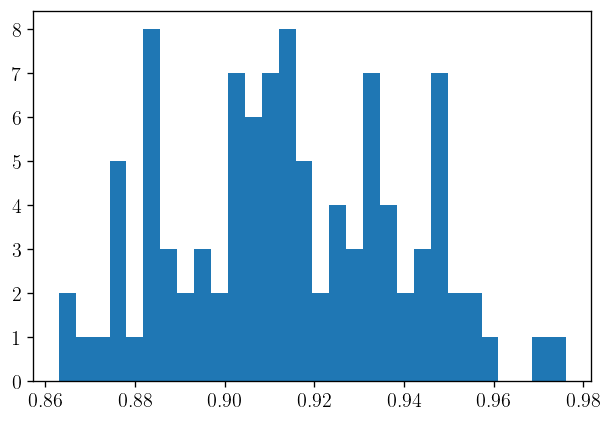

In [65]:
plt.hist([np.mean(z[~m.mask_roi]) for z in zs], bins=30);

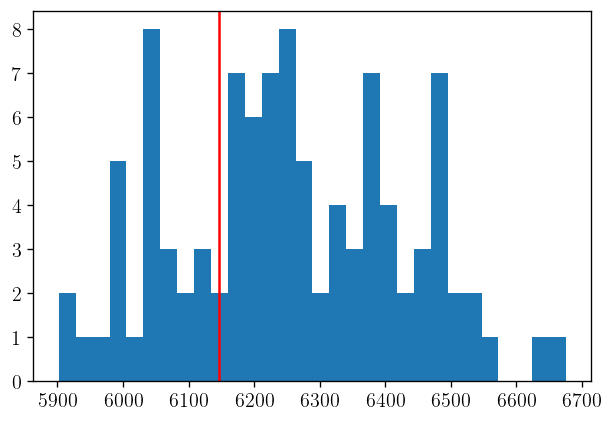

In [61]:
t = temps_ps[0]
exp_map = np.array(npmodel.exposure_map)
plt.hist(np.sum(zs, axis=-1), bins=30);
plt.axvline(12427.375 * (np.sum(t[~m.mask_roi]) / np.sum(t))*(np.mean(exp_map[~m.mask_roi]) / np.mean(exp_map)), color='r');

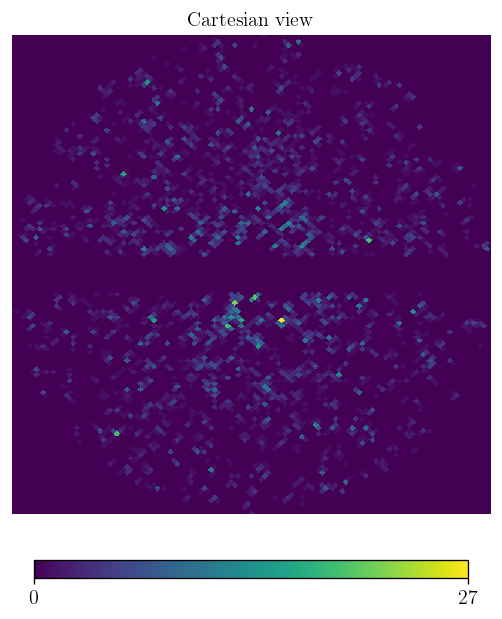

In [62]:
hp.cartview(z, lonra=[-25, 25], latra=[-25, 25])

In [18]:
np.mean(z[~npmodel.normalization_mask])

0.76000965

## 2. Likelihood

In [68]:
#@partial(jit, static_argnums=(0,2))
def ll(m, vd, data, S_gce, Sps_gce):

    if not m.non_poissonian:
        raise NotImplementedError

    theta_pib = vd['theta_pib']
    theta_ics = vd['theta_pib']
    temp_pib = jnp.sum(theta_pib[:, None] * m.pib, 0)
    temp_ics = jnp.sum(theta_ics[:, None] * m.ics, 0)

    #S_gce = vd['S_gce']
    temps = [m.temp_iso, m.temp_bub, m.temp_psc, temp_pib, temp_ics]
    temp_labels = ["iso", "bub", "psc", "pib", "ics"]
            
    mu = jnp.zeros_like(data)

    for temp, temp_label in zip(temps, temp_labels):
        S_temp = vd["S_{}".format(temp_label)]
        if temp_label in ["pib"]:
            temp_pib_mod = jnp.zeros_like(data)
            for ii in range(len(m.Ylm_temps)):
                Alm = vd["Alm_{}".format(ii)]
                temp_pib_mod += Alm * m.Ylm_temps[ii]
            temp_pib_mod = (1. + temp_pib_mod) * temp
            A_temp = S_temp / jnp.mean(temp_pib_mod[~m.normalization_mask])
            mu += A_temp * temp_pib_mod  
        else:
            A_temp = S_temp / jnp.mean(temp[~m.normalization_mask])
            mu += A_temp * temp     
                                        
    if m.vary_gamma:
        gamma_ps = vd["gamma_ps"]
        gamma_poiss = vd["gamma_poiss"]
    else:
        gamma_ps = 1.2
        gamma_poiss = 1.2
    temp_gce_nfw_ps = m.nfw_template.get_NFW2_template(gamma=gamma_ps)
    temp_gce_nfw_poiss = m.nfw_template.get_NFW2_template(gamma=gamma_poiss)

    if m.vary_disk:
        zs = vd["zs"]
        C = vd["C"]
        temp_dsk = m.disk_template.get_template(zs=zs, C=C)
    else:
        temp_dsk = m.temp_dsk
            
    if m.bulge_hybrid:
        f_bulge_ps = vd["f_bulge_ps"]
        f_bulge_poiss = vd["f_bulge_poiss"]
        theta_bulge_poiss = vd["theta_bulge_poiss"]
        temp_bulge = jnp.sum(theta_bulge_poiss[:, None] * m.bulge_templates, 0)
    else:
        f_bulge_ps = 0.
        f_bulge_poiss = vd["f_bulge_poiss"]
        temp_bulge = m.bulge_templates[0]

    A_gce_nfw = S_gce / jnp.mean(temp_gce_nfw_poiss[~m.normalization_mask])
    A_gce_bulge = S_gce / jnp.mean(temp_bulge[~m.normalization_mask])
    temp_gce_poiss = (1 - f_bulge_poiss) * A_gce_nfw * temp_gce_nfw_poiss \
                        + f_bulge_poiss * A_gce_bulge * temp_bulge

    A_gce = S_gce / jnp.mean(temp_gce_poiss[~m.normalization_mask])
    mu += A_gce * temp_gce_poiss

    theta_bulge_ps = vd["theta_bulge_ps"]
    temp_bulge = jnp.sum(theta_bulge_ps[:, None] * m.bulge_templates, 0)

    A_gce_nfw = 1 / jnp.mean(temp_gce_nfw_ps[~m.normalization_mask])
    A_gce_bulge = 1 / jnp.mean(temp_bulge[~m.normalization_mask])

    temp_gce_ps = (1 - f_bulge_ps) * A_gce_nfw * temp_gce_nfw_ps + f_bulge_ps * A_gce_bulge * temp_bulge
    npt_compressed = jnp.array([temp_gce_ps, temp_dsk])
    theta = []    
    for ips, ps in enumerate(["gce", "dsk"]):
        Sps = vd["Sps_{}".format(ps)]
        if ps == 'gce':
            Sps = Sps_gce
        n1 = vd["n1_{}".format(ps)]
        n2 = vd["n2_{}".format(ps)]
        n3 = vd["n3_{}".format(ps)]
        sb1 = vd["sb1_{}".format(ps)]
        lambda_s = vd["lambdas_{}".format(ps)]
        theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])
        s_ary = jnp.logspace(0., 2, 100)
        dnds_ary = dnds(s_ary, theta_tmp)
        A = Sps / jnp.mean(npt_compressed[ips][~m.normalization_mask] * jnp.trapz(s_ary * dnds_ary, s_ary))
        theta.append([A, n1, n2, n3, sb1, lambda_s * sb1])
    theta = jnp.array(theta)
    
    mu_masked = mu[~m.mask_roi]
    npt_compressed_masked = npt_compressed[:, ~m.mask_roi]
    data_masked = data[~m.mask_roi]
    ll_arr = log_like_np(theta, mu_masked, npt_compressed_masked, data_masked, m.f_ary, m.df_rho_div_f_ary, m.k_max, len(mu_masked))
    return jnp.sum(ll_arr)

In [69]:
S_Sps_arr = [[5., 0.01], [2.5, 2.5], [0.01, 5.]]
ll_arr_arr = []
for S_gce, Sps_gce in S_Sps_arr:
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"
    print(run_name)

    counts = jnp.array(jnp.load(f"counts-{run_name}-bare.npy"), dtype=np.int32)
    var_dict = pickle.load(open(f"truth-{run_name}-bare.p", 'rb'))

    S_arr = np.geomspace(1e-2, 10, 30)
    Sps_arr = np.geomspace(1e-2, 10, 30)
    ll_arr = np.zeros((len(S_arr), len(Sps_arr)))
    for i_S, S in enumerate(tqdm(S_arr)):
        for i_Sps, Sps in enumerate(Sps_arr):
            ll_arr[i_S, i_Sps] = ll(npmodel, var_dict, counts, S, Sps)
    ll_arr_arr.append(ll_arr)

S5.000Sps0.010


100%|██████████| 30/30 [00:52<00:00,  1.74s/it]


S2.500Sps2.500


100%|██████████| 30/30 [00:44<00:00,  1.50s/it]


S0.010Sps5.000


100%|██████████| 30/30 [00:45<00:00,  1.50s/it]


/tmp/ipykernel_1317345/2497261555.py:6: UserWarning: The following kwargs were not used by contour: 'aspect'
  ct = axs[i].contour((Sps_arr), (S_arr), ll_arr-np.max(ll_arr), levels=[-10000, -5000, -2500, -1000, -100, -10, -1], aspect=1)


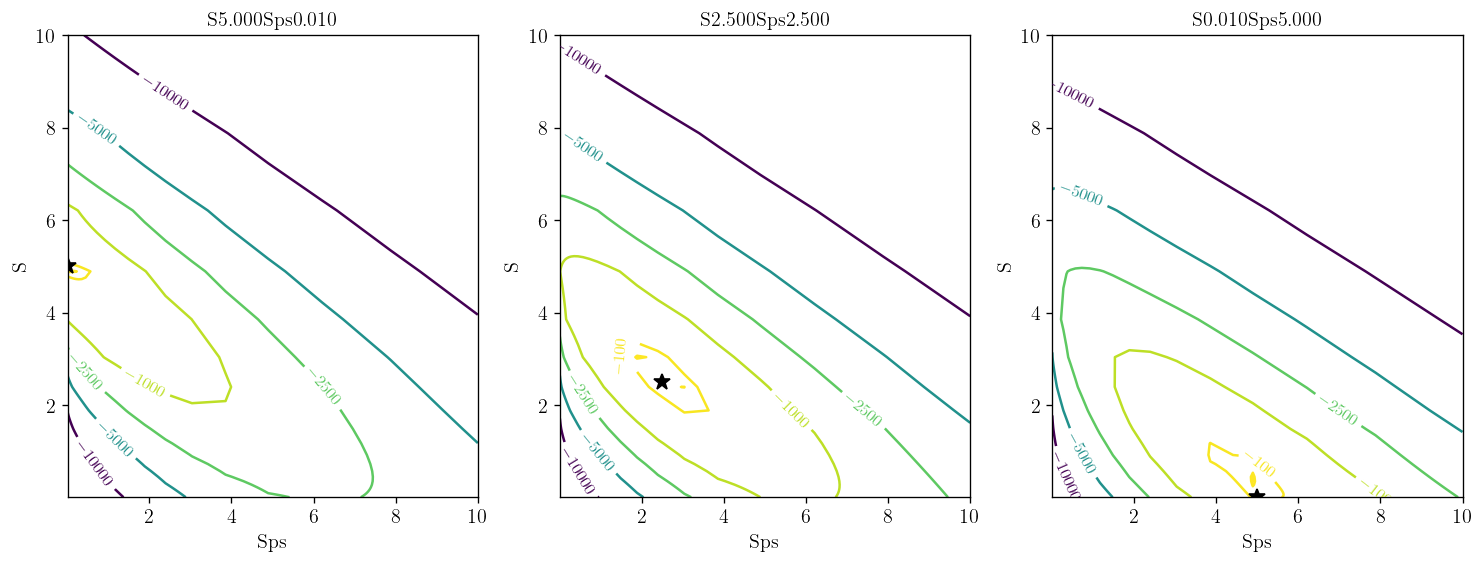

In [70]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, ll_arr in enumerate(ll_arr_arr):
    S_gce, Sps_gce = S_Sps_arr[i]
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"
    # show contour labels
    ct = axs[i].contour((Sps_arr), (S_arr), ll_arr-np.max(ll_arr), levels=[-10000, -5000, -2500, -1000, -100, -10, -1], aspect=1)
    axs[i].clabel(ct, inline=True, fontsize=10)
    axs[i].set(xlabel="Sps", ylabel="S", title=run_name)
    axs[i].plot(Sps_gce, S_gce, '*', color='k', ms=10)